# Practical 2: Applying a CNN to an Image Dataset

**Objective:**

Download an image dataset directly from a link, build a Convolutional Neural Network,
train it, and evaluate how well it classifies unseen images.

**Dataset:** CIFAR-10 (as real `.jpg` image files arranged in class folders)

**Direct link:** `https://github.com/YoongiKim/CIFAR-10-images.git`

| Property | Value |
|---|---|
| Images | 60,000 (50,000 train + 10,000 test) |
| Image size | 32 x 32 pixels, RGB (3 channels) |
| Classes | 10 — airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck |
| Format | Individual `.jpg` files inside one folder per class |

In [2]:
import os

DATA_DIR = "CIFAR-10-images"
DATASET_URL = "https://github.com/YoongiKim/CIFAR-10-images.git"

if not os.path.exists(DATA_DIR):
    print("Downloading dataset from:", DATASET_URL)
    os.system("git clone --depth 1 -q " + DATASET_URL)
else:
    print("Dataset already present, skipping download.")

TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR  = os.path.join(DATA_DIR, "test")

print()
print("Train folder :", TRAIN_DIR)
print("Test folder  :", TEST_DIR)
print("Classes found:", sorted(os.listdir(TRAIN_DIR)))


Train folder : CIFAR-10-images/train
Test folder  : CIFAR-10-images/test
Classes found: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [3]:
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow :", tf.__version__)
print("NumPy      :", np.__version__)
print("Seed fixed at", SEED)

TensorFlow : 2.20.0
NumPy      : 2.1.3
Seed fixed at 42


In [4]:
from matplotlib.colors import LinearSegmentedColormap

BLUE   = "#2a78d6"     # training / primary series
ORANGE = "#eb6834"     # validation / second series
INK    = "#0b0b0b"
MUTED  = "#52514e"

# single-hue sequential ramp for the confusion matrix
BLUE_RAMP = ["#fcfcfb", "#cde2fb", "#9ec5f4", "#6da7ec",
             "#3987e5", "#256abf", "#184f95", "#0d366b"]
CMAP_BLUE = LinearSegmentedColormap.from_list("seq_blue", BLUE_RAMP)

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor":   "#fcfcfb",
    "axes.edgecolor":   "#c9c8c3",
    "axes.labelcolor":  MUTED,
    "text.color":       INK,
    "xtick.color":      MUTED,
    "ytick.color":      MUTED,
    "axes.grid":        True,
    "grid.color":       "#e6e5e1",
    "grid.linewidth":   0.8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "lines.linewidth":  2,
    "font.size":        10,
    "figure.dpi":       110,
})

print("Chart style applied.")

Chart style applied.


In [5]:
IMG_SIZE   = (32, 32)
BATCH_SIZE = 64

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    validation_split=0.1, subset="training", seed=SEED)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    validation_split=0.1, subset="validation", seed=SEED)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)

print()
print("Classes:", CLASS_NAMES)

for images, labels in train_ds.take(1):
    print("One batch of images :", images.shape)   # (batch, height, width, channels)
    print("One batch of labels :", labels.shape)
    print("Pixel value range   :", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))

Found 50000 files belonging to 10 classes.
Using 45000 files for training.
Found 50000 files belonging to 10 classes.
Using 5000 files for validation.
Found 10000 files belonging to 10 classes.

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
One batch of images : (64, 32, 32, 3)
One batch of labels : (64,)
Pixel value range   : 0.0 to 255.0


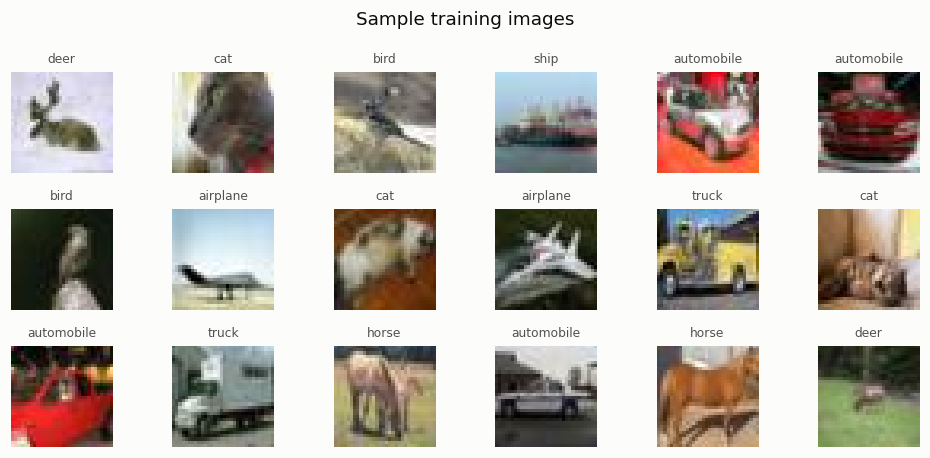

In [6]:
plt.figure(figsize=(9, 4.2))
for images, labels in train_ds.take(1):
    for i in range(18):
        ax = plt.subplot(3, 6, i + 1)
        ax.imshow(images[i].numpy().astype("uint8"))
        ax.set_title(CLASS_NAMES[labels[i]], fontsize=8, color=MUTED)
        ax.axis("off")
        ax.grid(False)
plt.suptitle("Sample training images", fontsize=12, color=INK)
plt.tight_layout()
plt.show()

In [7]:
counts = [len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in CLASS_NAMES]

print("Images per class in the train folder")
print("-" * 40)
for name, n in zip(CLASS_NAMES, counts):
    print("  {:<12} {:>6}".format(name, n))
print("-" * 40)
print("  {:<12} {:>6}".format("TOTAL", sum(counts)))
print()
print("Balanced dataset:", len(set(counts)) == 1)

Images per class in the train folder
----------------------------------------
  airplane       5000
  automobile     5000
  bird           5000
  cat            5000
  deer           5000
  dog            5000
  frog           5000
  horse          5000
  ship           5000
  truck          5000
----------------------------------------
  TOTAL         50000

Balanced dataset: True


In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

print("Input pipeline ready (cache -> shuffle -> prefetch).")

Input pipeline ready (cache -> shuffle -> prefetch).


The training set is finite, so the model can simply memorise it. Augmentation creates
slightly modified copies on the fly — flipped, rotated, zoomed — so the model has to learn
the *object* instead of the exact pixels. This directly reduces overfitting.

Augmentation is applied **only during training**; Keras automatically switches it off at
validation and test time.

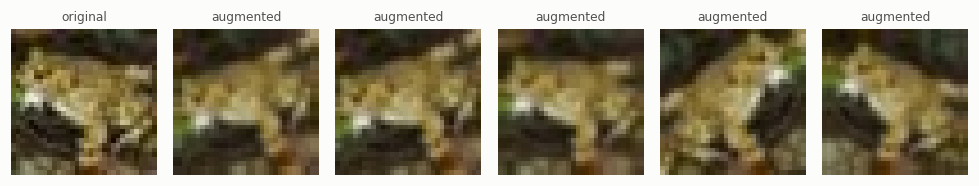

In [9]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
], name="data_augmentation")

# Show the same image augmented several times
for images, _ in train_ds.take(1):
    sample = images[0]
    plt.figure(figsize=(9, 2.1))
    for i in range(6):
        ax = plt.subplot(1, 6, i + 1)
        if i == 0:
            ax.imshow(sample.numpy().astype("uint8"))
            ax.set_title("original", fontsize=8, color=MUTED)
        else:
            aug = data_augmentation(tf.expand_dims(sample, 0), training=True)
            ax.imshow(aug[0].numpy().astype("uint8"))
            ax.set_title("augmented", fontsize=8, color=MUTED)
        ax.axis("off")
        ax.grid(False)
    plt.tight_layout()
    plt.show()

The network is three convolution blocks followed by a classifier head.

| Layer | Why it is there |
|---|---|
| `Rescaling(1/255)` | Brings pixels from 0–255 into 0–1 so training is stable |
| `Conv2D` | Learns filters — edges and colours early, shapes and parts later |
| `BatchNormalization` | Keeps activations well-scaled, speeds up and stabilises training |
| `MaxPooling2D` | Halves the spatial size, keeps the strongest response, adds shift tolerance |
| `Dropout` | Randomly switches off neurons during training to prevent overfitting |
| `Dense(10, softmax)` | Produces the probability of each of the 10 classes |

Notice the filter count **increases** (32 → 64 → 128) while the image size **decreases**
(32 → 16 → 8 → 4). Early layers see a lot of pixels but few patterns; deeper layers see
few pixels but many patterns.

In [10]:
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Rescaling(1.0 / 255),
    data_augmentation,

    # Block 1
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Classifier head
    layers.Flatten(),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax"),
], name="CNN_CIFAR10")

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

model.summary()

Model: "CNN_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

Two callbacks are used:

* **EarlyStopping** — stops training when validation accuracy stops improving and restores
  the best weights, so the saved model is never the overfitted one.
* **ReduceLROnPlateau** — lowers the learning rate when progress stalls, which lets the
  model settle into a better minimum.

In [11]:
EPOCHS = 15

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=4,
        restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=2, min_lr=1e-5, verbose=1),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=2)

print()
print("Training finished. Epochs actually run:", len(history.history["accuracy"]))

Epoch 1/15
704/704 - 15s - 21ms/step - accuracy: 0.4436 - loss: 1.5582 - val_accuracy: 0.4778 - val_loss: 1.5583 - learning_rate: 0.0010
Epoch 2/15
704/704 - 8s - 12ms/step - accuracy: 0.5491 - loss: 1.2569 - val_accuracy: 0.5206 - val_loss: 1.4290 - learning_rate: 0.0010
Epoch 3/15
704/704 - 7s - 11ms/step - accuracy: 0.5924 - loss: 1.1418 - val_accuracy: 0.5972 - val_loss: 1.1306 - learning_rate: 0.0010
Epoch 4/15
704/704 - 8s - 11ms/step - accuracy: 0.6205 - loss: 1.0734 - val_accuracy: 0.6060 - val_loss: 1.1149 - learning_rate: 0.0010
Epoch 5/15
704/704 - 8s - 11ms/step - accuracy: 0.6398 - loss: 1.0183 - val_accuracy: 0.5234 - val_loss: 1.5219 - learning_rate: 0.0010
Epoch 6/15

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
704/704 - 9s - 13ms/step - accuracy: 0.6537 - loss: 0.9799 - val_accuracy: 0.6062 - val_loss: 1.2061 - learning_rate: 0.0010
Epoch 7/15
704/704 - 9s - 13ms/step - accuracy: 0.6844 - loss: 0.9002 - val_accuracy: 0.6878 - val_loss: 0

Two things to read from these charts:

* If the **training** curve keeps improving while the **validation** curve flattens or turns
  the other way, the model is overfitting.
* If both curves are still climbing at the end, the model could be trained for longer.

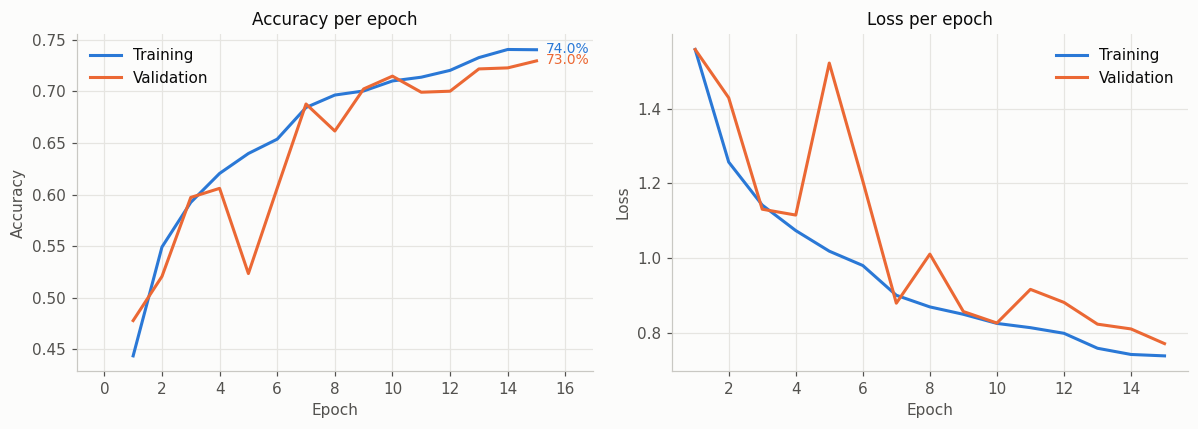

Best validation accuracy: 72.96% (epoch 15)


In [12]:
hist   = history.history
epochs = range(1, len(hist["accuracy"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# --- Accuracy ---
ax = axes[0]
ax.plot(epochs, hist["accuracy"],     color=BLUE,   label="Training")
ax.plot(epochs, hist["val_accuracy"], color=ORANGE, label="Validation")
ax.set_title("Accuracy per epoch", color=INK, fontsize=11)
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.legend(frameon=False)
ax.margins(x=0.14)                       # room for the end-of-line labels
# direct labels on the final values
ax.annotate("{:.1%}".format(hist["accuracy"][-1]),
            (epochs[-1], hist["accuracy"][-1]),
            textcoords="offset points", xytext=(6, -2), color=BLUE, fontsize=9)
ax.annotate("{:.1%}".format(hist["val_accuracy"][-1]),
            (epochs[-1], hist["val_accuracy"][-1]),
            textcoords="offset points", xytext=(6, -2), color=ORANGE, fontsize=9)

# --- Loss ---
ax = axes[1]
ax.plot(epochs, hist["loss"],     color=BLUE,   label="Training")
ax.plot(epochs, hist["val_loss"], color=ORANGE, label="Validation")
ax.set_title("Loss per epoch", color=INK, fontsize=11)
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

print("Best validation accuracy: {:.2%} (epoch {})".format(
    max(hist["val_accuracy"]), int(np.argmax(hist["val_accuracy"])) + 1))

This is the number that actually matters — the model has never seen these 10,000 images.

In [13]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

print("=" * 44)
print("  Test accuracy : {:.2%}".format(test_acc))
print("  Test loss     : {:.4f}".format(test_loss))
print("=" * 44)
print()
print("Random guessing would give {:.0%}.".format(1 / NUM_CLASSES))
print("The CNN is about {:.1f}x better than chance.".format(test_acc * NUM_CLASSES))

  Test accuracy : 73.67%
  Test loss     : 0.7578

Random guessing would give 10%.
The CNN is about 7.4x better than chance.


The rows are the true classes and the columns are what the model predicted. A perfect
model would put every image on the diagonal. The interesting information is **off** the
diagonal — it shows which classes the model mixes up.

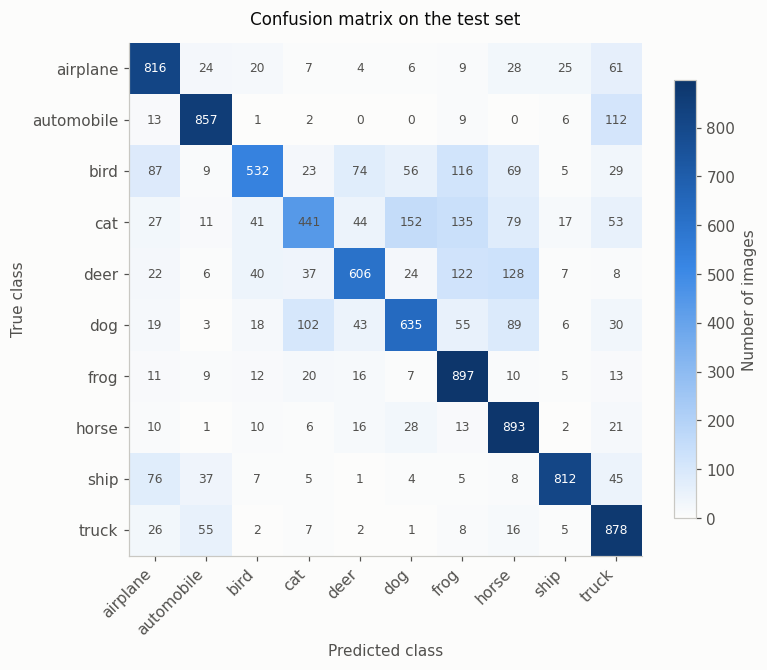

In [14]:
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7.2, 6.2))
im = ax.imshow(cm, cmap=CMAP_BLUE)
ax.grid(False)

ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted class"); ax.set_ylabel("True class")
ax.set_title("Confusion matrix on the test set", color=INK, fontsize=11, pad=12)

# write the count inside every cell
threshold = cm.max() * 0.55
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                color="#ffffff" if cm[i, j] > threshold else MUTED)

fig.colorbar(im, ax=ax, shrink=0.8, label="Number of images")
plt.tight_layout()
plt.show()

In [15]:
# Which pairs of classes get confused the most?
mistakes = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j:
            mistakes.append((cm[i, j], CLASS_NAMES[i], CLASS_NAMES[j]))
mistakes.sort(reverse=True)

print("Top 5 confusions (true -> predicted)")
print("-" * 44)
for n, true_c, pred_c in mistakes[:5]:
    print("  {:<10} mistaken for {:<12} {:>4} times".format(true_c, pred_c, n))

Top 5 confusions (true -> predicted)
--------------------------------------------
  cat        mistaken for dog           152 times
  cat        mistaken for frog          135 times
  deer       mistaken for horse         128 times
  deer       mistaken for frog          122 times
  bird       mistaken for frog          116 times


Overall accuracy hides the detail. Some classes are much easier than others.

In [16]:
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))

              precision    recall  f1-score   support

    airplane      0.737     0.816     0.775      1000
  automobile      0.847     0.857     0.852      1000
        bird      0.779     0.532     0.632      1000
         cat      0.678     0.441     0.535      1000
        deer      0.752     0.606     0.671      1000
         dog      0.696     0.635     0.664      1000
        frog      0.655     0.897     0.757      1000
       horse      0.677     0.893     0.770      1000
        ship      0.912     0.812     0.859      1000
       truck      0.702     0.878     0.780      1000

    accuracy                          0.737     10000
   macro avg      0.744     0.737     0.729     10000
weighted avg      0.744     0.737     0.729     10000



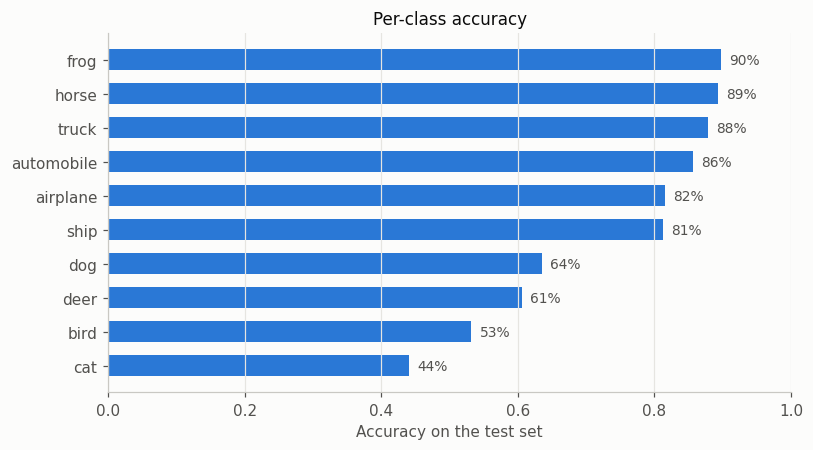

Easiest class : frog         89.7%
Hardest class : cat          44.1%


In [17]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)
order = np.argsort(per_class_acc)                  # worst at the bottom

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.barh([CLASS_NAMES[i] for i in order], per_class_acc[order],
        color=BLUE, height=0.6)
ax.set_xlim(0, 1)
ax.set_xlabel("Accuracy on the test set")
ax.set_title("Per-class accuracy", color=INK, fontsize=11)
ax.grid(axis="y", visible=False)

for y, i in enumerate(order):                      # direct label on each bar
    ax.text(per_class_acc[i] + 0.012, y, "{:.0%}".format(per_class_acc[i]),
            va="center", fontsize=9, color=MUTED)

plt.tight_layout()
plt.show()

print("Easiest class : {:<12} {:.1%}".format(
    CLASS_NAMES[int(np.argmax(per_class_acc))], per_class_acc.max()))
print("Hardest class : {:<12} {:.1%}".format(
    CLASS_NAMES[int(np.argmin(per_class_acc))], per_class_acc.min()))

Numbers are easier to trust once the individual predictions have been seen. Correct
predictions are titled in blue, mistakes in orange with the true label in brackets.

The test folder is stored class by class, so taking the first few images would show only
one class. Instead, 18 images are sampled at random from across the whole test set.

Images available for display: (10000, 32, 32, 3)


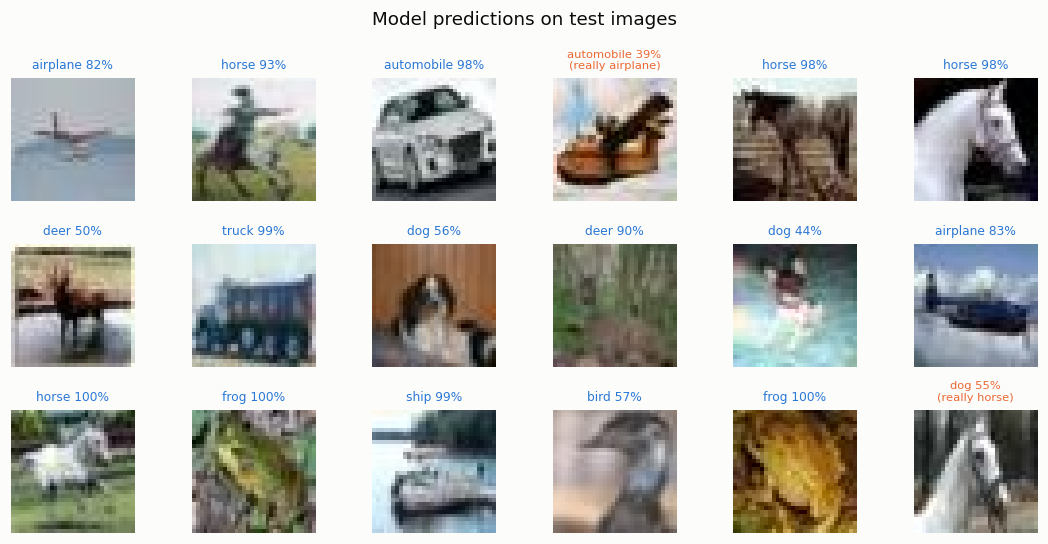

Correct in this sample of 18: 16


In [18]:
# test_ds was loaded with shuffle=False, so these images line up exactly
# with y_true / y_pred / y_prob computed in Step 12.
all_images = np.concatenate([x.numpy().astype("uint8") for x, _ in test_ds])
print("Images available for display:", all_images.shape)

rng   = np.random.default_rng(SEED)
picks = rng.choice(len(all_images), size=18, replace=False)

plt.figure(figsize=(10, 5))
for k, idx in enumerate(picks):
    ax = plt.subplot(3, 6, k + 1)
    ax.imshow(all_images[idx])
    ax.axis("off"); ax.grid(False)

    pred = int(y_pred[idx])
    true = int(y_true[idx])
    conf = y_prob[idx][pred]

    if pred == true:
        ax.set_title("{} {:.0f}%".format(CLASS_NAMES[pred], conf * 100),
                     fontsize=8, color=BLUE)
    else:
        ax.set_title("{} {:.0f}%\n(really {})".format(
            CLASS_NAMES[pred], conf * 100, CLASS_NAMES[true]),
            fontsize=7.5, color=ORANGE)

plt.suptitle("Model predictions on test images", fontsize=12, color=INK)
plt.tight_layout()
plt.show()

n_right = int((y_pred[picks] == y_true[picks]).sum())
print("Correct in this sample of 18:", n_right)

A well-behaved model should be less confident on the images it gets wrong. If it is
equally confident on its mistakes, the predictions cannot be trusted.

There are far more correct predictions than wrong ones, so plotting raw counts would make
the "wrong" group almost invisible. Each group is therefore shown as a **percentage of
itself**, which compares the two shapes fairly.

Mean confidence when CORRECT : 84.1%
Mean confidence when WRONG   : 58.1%



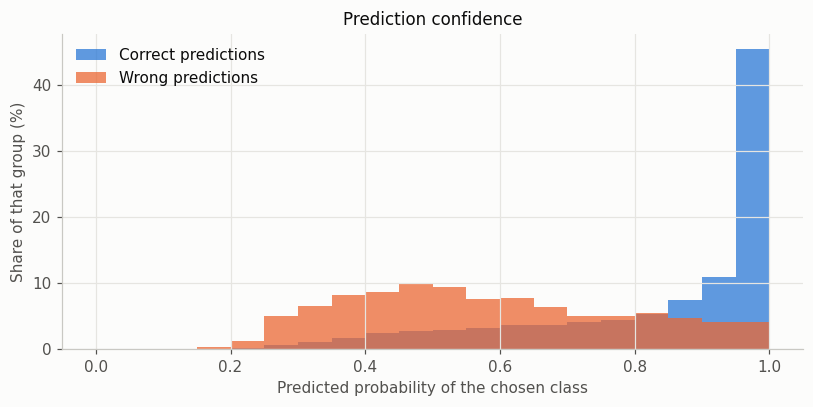

In [19]:
confidence = y_prob.max(axis=1)
correct    = (y_pred == y_true)

print("Mean confidence when CORRECT : {:.1%}".format(confidence[correct].mean()))
print("Mean confidence when WRONG   : {:.1%}".format(confidence[~correct].mean()))
print()

fig, ax = plt.subplots(figsize=(7.5, 3.8))
bins = np.linspace(0, 1, 21)

# weight each group so its bars add up to 100% of that group
w_right = np.full(int(correct.sum()),    100.0 / int(correct.sum()))
w_wrong = np.full(int((~correct).sum()), 100.0 / int((~correct).sum()))

ax.hist(confidence[correct],  bins=bins, weights=w_right,
        color=BLUE,   alpha=0.75, label="Correct predictions")
ax.hist(confidence[~correct], bins=bins, weights=w_wrong,
        color=ORANGE, alpha=0.75, label="Wrong predictions")
ax.set_xlabel("Predicted probability of the chosen class")
ax.set_ylabel("Share of that group (%)")
ax.set_title("Prediction confidence", color=INK, fontsize=11)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [20]:
model.save("cnn_cifar10.keras")

size_mb = os.path.getsize("cnn_cifar10.keras") / (1024 * 1024)
print("Model saved as cnn_cifar10.keras ({:.1f} MB)".format(size_mb))
print("Trainable parameters:", format(model.count_params(), ","))

# Reload it to prove the saved file works
reloaded = tf.keras.models.load_model("cnn_cifar10.keras")
_, reloaded_acc = reloaded.evaluate(test_ds, verbose=0)
print("Accuracy after reloading: {:.2%}".format(reloaded_acc))

Model saved as cnn_cifar10.keras (4.2 MB)
Trainable parameters: 357,706
Accuracy after reloading: 73.67%


## Conclusion

A CNN was trained on 45,000 CIFAR-10 images downloaded directly from a public repository
and tested on 10,000 images it had never seen.

**What the results show**

1. The model learns real visual features, not noise — test accuracy is far above the 10%
   a random guess would give on 10 classes.
2. Validation accuracy tracks training accuracy closely. Augmentation and dropout are
   doing their job; without them the training curve would run away from the validation
   curve.
3. The confusion matrix shows the errors are **sensible**: cats and dogs are mixed up with
   each other, and automobiles with trucks. These pairs genuinely look alike at
   32 x 32 resolution, which is what a human would also struggle with.
4. Vehicles are classified more accurately than animals, because vehicles have rigid
   shapes and straight edges while animals vary in pose, colour and background.
5. The model is noticeably less confident on the images it gets wrong, which means its
   probability output carries useful information.

**Why a CNN suits this task**

* **Local receptive fields** — each filter looks at a small patch and learns edges,
  corners and textures.
* **Weight sharing** — one filter is reused across the whole image, so the parameter
  count stays small and independent of image size.
* **Pooling** — gives tolerance to small shifts, so an object is recognised wherever it
  appears in the frame.
* **Hierarchy** — early layers detect edges, deeper layers combine them into shapes and
  finally into objects.

A fully connected network on the same images would need a separate weight for every pixel
of every neuron, losing all spatial structure at the input and requiring far more
parameters for worse results.

**How this could be improved further**

* Train for more epochs — the curves suggest the model has not fully converged.
* Add more convolution blocks, or two convolutions per block before pooling.
* Use transfer learning from a network pre-trained on ImageNet.
* Feed larger images; 32 x 32 discards a lot of detail before learning even begins.

*Abu Sayem*